# Lavrentiev regularization with shift unfolding of an IAEA Compendium spectrum (`unfold_lavrentiev`)

This notebook applies the Lavrentiev regularization with shift (also known
as shifted Tikhonov regularization) to the unfolding problem:

> M. M. Lavrentiev, *Some Improperly Posed Problems of Mathematical Physics*,
> Springer, 1967.

The method solves the ill-posed linear system $A\phi = b$ by replacing it
with the regularized normal system

$$(A^T A + \alpha I)\,\phi = A^T b + \alpha\,\phi_0,$$

where $\phi_0$ is an a-priori guess of the solution (the shift) and
$\alpha > 0$ is the regularization parameter.  This is equivalent to
minimizing the functional

$$\min_{\phi} \; \|A\phi - b\|^2 + \alpha \|\phi - \phi_0\|^2.$$

For square matrices the classical Lavrentiev method solves
$(A + \alpha I)\phi = b + \alpha\phi_0$ directly; the normal-system form
above is the standard generalization that works for rectangular matrices
($m \neq n$) without any zero-padding.

In [1]:
# %pip install bssunfold pandas numpy matplotlib

## 1. Detector response functions

We use the built-in GSF response functions (10 Bonner spheres, `0in` -
`18in`, 60 energy bins from 1e-9 to ~631 MeV).

Detector grid: 60 bins, 1.0e-09 - 631.0 MeV
Spheres: 0in, 2in, 3in, 5in, 6in, 8in, 10in, 12in, 15in, 18in


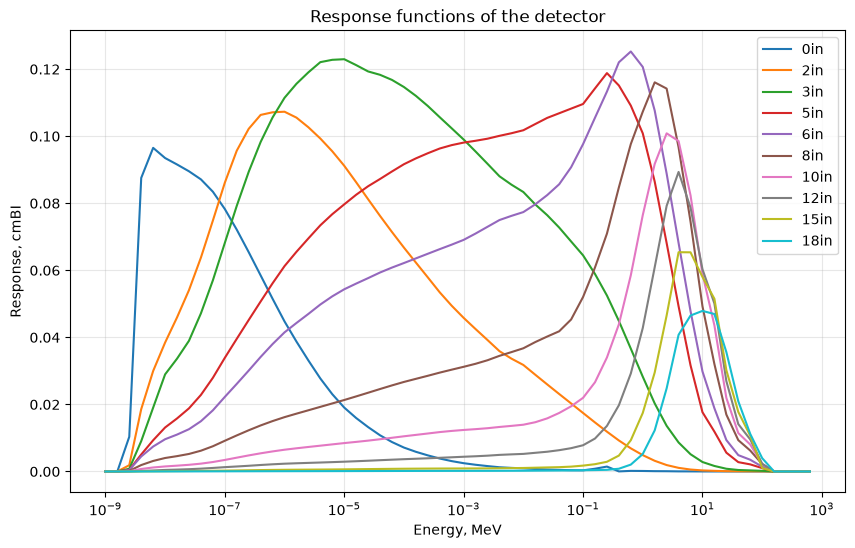

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bssunfold import Detector, RF_GSF
from bssunfold.utils.comparison import compare_spectra

detector = Detector(RF_GSF)
E = detector.E_MeV
names = detector.detector_names
print(f"Detector grid: {detector.n_energy_bins} bins, "
      f"{E[0]:.1e} - {E[-1]:.1f} MeV")
print("Spheres:", ", ".join(names))
detector.plot_response_functions()

## 2. IAEA Compendium reference spectrum -> detector readings

The compendium CSV stores 61-point Monte-Carlo spectra on its own energy
grid, which differs slightly from the 60-bin detector grid, so the
ground truth is interpolated onto the detector grid *for evaluation
only*.  The readings are the spectrum folded with the response
functions.

Reference CSV: 61 rows, 20 spectra, 1.0e-09 - 631 MeV
Effective readings:
    0in: 0.06677
    2in: 0.0901
    3in: 0.1382
    5in: 0.1639
    6in: 0.1407
    8in: 0.08047
   10in: 0.03924
   12in: 0.01789
   15in: 0.006419
   18in: 0.003085


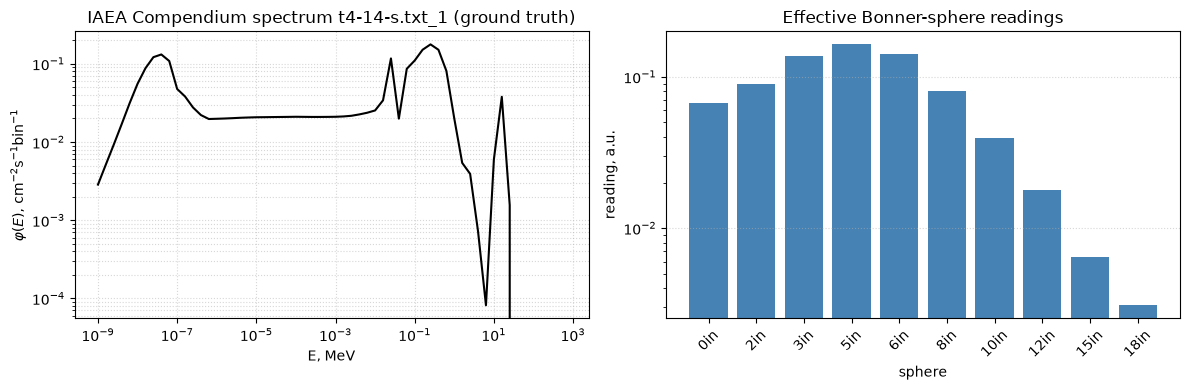

In [3]:
reference_csv = pd.read_csv(
    '../tests/MonteCarlo_Calculated_spectra_from_IAEA_Comp_for_comparison.csv'
)
print(f"Reference CSV: {len(reference_csv)} rows, "
      f"{len(reference_csv.columns) - 1} spectra, "
      f"{reference_csv['E_MeV'].min():.1e} - "
      f"{reference_csv['E_MeV'].max():.0f} MeV")

SPECTRUM = 't4-14-s.txt_1'   # IAEA Compendium BSA benchmark case

readings = detector.get_effective_readings_for_spectra(
    reference_csv[['E_MeV', SPECTRUM]]
)
print("Effective readings:")
for nm in names:
    print(f"  {nm:>5s}: {readings[nm]:.4g}")

# Ground truth on the detector grid (for evaluation only)
phi_true = np.interp(
    E, reference_csv['E_MeV'].values, reference_csv[SPECTRUM].values
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
ax.loglog(E, phi_true, "k-", lw=1.5)
ax.set(xlabel="E, MeV", ylabel=r"$\varphi(E)$, cm$^{-2}$s$^{-1}$bin$^{-1}$",
       title=f"IAEA Compendium spectrum {SPECTRUM} (ground truth)")
ax.grid(True, which="both", ls=":", alpha=0.5)

ax = axes[1]
vals = [readings[nm] for nm in names]
ax.bar(np.arange(len(names)), vals, color="steelblue")
ax.set_yscale("log")
ax.set_xticks(np.arange(len(names)))
ax.set_xticklabels(names, rotation=45)
ax.set(xlabel="sphere", ylabel="reading, a.u.",
       title="Effective Bonner-sphere readings")
ax.grid(True, axis="y", ls=":", alpha=0.5)
fig.tight_layout()
plt.show()

## 3. Unfold with Lavrentiev regularization

Two regularization strengths are demonstrated:

* **weak regularization** (`alpha=0.01`) — close to the least-squares
  solution, fits the data well but may be noisy;
* **strong regularization** (`alpha=1.0`) — smoother solution, anchored
  to the a-priori spectrum.

The energy cutoff `max_neutron_energy=20.0` confines the solution to
the range covered by the benchmark spectrum.


weak (alpha=0.01):
  method        : Lavrentiev
  alpha         : 0.01
  residual norm : 1.146e-02
  quality vs ground truth:
    relative_flux_error           : 0.532
    pearson_r                     : 0.736
    comprehensive_score           : 0.164

strong (alpha=1.0):
  method        : Lavrentiev
  alpha         : 1.0
  residual norm : 1.493e-01
  quality vs ground truth:
    relative_flux_error           : 0.810
    pearson_r                     : 0.329
    comprehensive_score           : 0.645


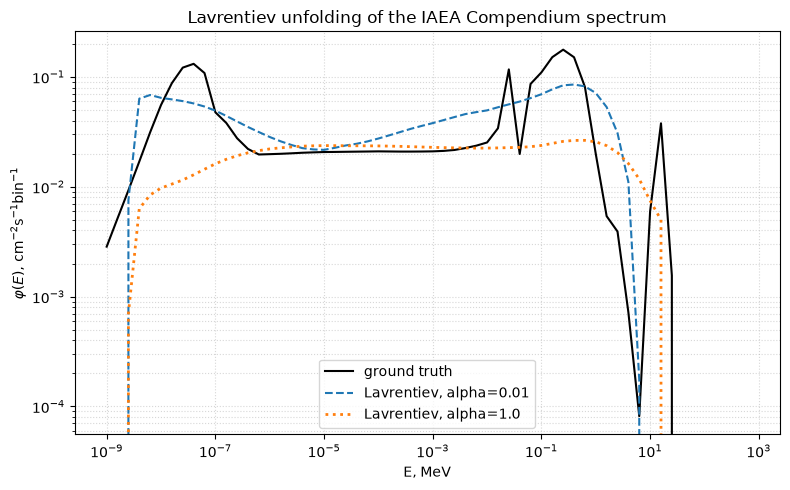

In [4]:
result_weak = detector.unfold_lavrentiev(
    readings,
    alpha=0.01,
    max_neutron_energy=20.0,
    save_result=False,
)

result_strong = detector.unfold_lavrentiev(
    readings,
    alpha=1.0,
    max_neutron_energy=20.0,
    save_result=False,
)

for label, result in [("weak (alpha=0.01)", result_weak),
                      ("strong (alpha=1.0)", result_strong)]:
    print(f"\n{label}:")
    print(f"  method        : {result['method']}")
    print(f"  alpha         : {result['alpha']}")
    print(f"  residual norm : {result['residual_norm']:.3e}")
    metrics = compare_spectra(
        phi_true, result["spectrum"],
        metrics=["relative_flux_error", "pearson_r", "comprehensive_score"],
    )
    print("  quality vs ground truth:")
    for key, val in metrics.items():
        print(f"    {key:<30s}: {val:.3f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(E, phi_true, "k-", lw=1.5, label="ground truth")
ax.loglog(E, result_weak["spectrum"], "--", lw=1.5,
          label="Lavrentiev, alpha=0.01")
ax.loglog(E, result_strong["spectrum"], ":", lw=2.0,
          label="Lavrentiev, alpha=1.0")
ax.set(xlabel="E, MeV", ylabel=r"$\varphi(E)$, cm$^{-2}$s$^{-1}$bin$^{-1}$",
       title="Lavrentiev unfolding of the IAEA Compendium spectrum")
ax.legend()
ax.grid(True, which="both", ls=":", alpha=0.5)
fig.tight_layout()
plt.show()

## 4. Regularization parameter sweep

The regularization parameter $\alpha$ controls the trade-off between
data fidelity and smoothness.  Small $\alpha$ gives a solution close to
the least-squares fit (noisy), while large $\alpha$ pulls the solution
toward the a-priori spectrum (smooth but biased).

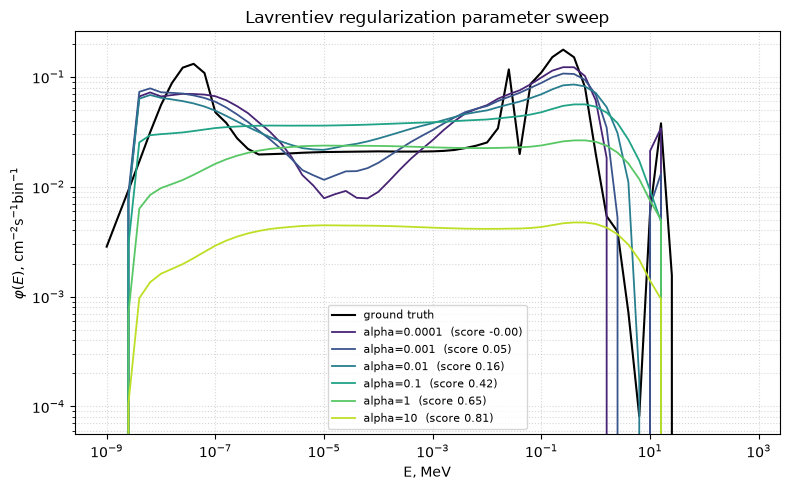

In [5]:
alphas = [1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0]

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(E, phi_true, "k-", lw=1.5, label="ground truth")
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(alphas)))
for color, alpha in zip(colors, alphas):
    res = detector.unfold_lavrentiev(
        readings, alpha=alpha, max_neutron_energy=20.0, save_result=False,
    )
    m = compare_spectra(phi_true, res["spectrum"],
                        metrics=["comprehensive_score"])
    ax.loglog(E, res["spectrum"], lw=1.3, color=color,
              label=f"alpha={alpha:g}  (score {m['comprehensive_score']:.2f})")
ax.set(xlabel="E, MeV", ylabel=r"$\varphi(E)$, cm$^{-2}$s$^{-1}$bin$^{-1}$",
       title="Lavrentiev regularization parameter sweep")
ax.legend(fontsize=8)
ax.grid(True, which="both", ls=":", alpha=0.5)
fig.tight_layout()
plt.show()

## 5. Informed a-priori spectrum

The Lavrentiev method anchors the solution to the a-priori spectrum
$\phi_0$ through the shift term $\alpha\phi_0$.  A physically informed
a-priori (here: the ground-truth shape at half scale with a constant
offset — as if taken from a prior measurement or a shield-design
calculation) substantially improves the recovery of the underdetermined
spectral components.

quality vs ground truth (informed a-priori):
  relative_flux_error           : 0.673
  pearson_r                     : 0.515
  comprehensive_score           : 0.416


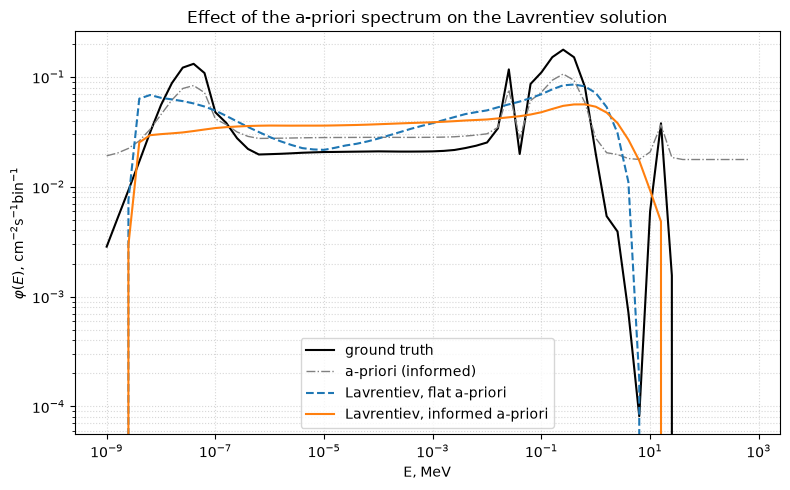

In [6]:
phi_prior = 0.5 * phi_true + 0.1 * np.max(phi_true)
Emax = 20.0
active = E <= Emax
result_prior = detector.unfold_lavrentiev(
    readings,
    initial_spectrum=phi_prior[active],
    alpha=0.1,
    max_neutron_energy=Emax,
    save_result=False,
)

metrics_prior = compare_spectra(
    phi_true, result_prior["spectrum"],
    metrics=["relative_flux_error", "pearson_r", "comprehensive_score"],
)
print("quality vs ground truth (informed a-priori):")
for key, val in metrics_prior.items():
    print(f"  {key:<30s}: {val:.3f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(E, phi_true, "k-", lw=1.5, label="ground truth")
ax.loglog(E, phi_prior, "-.", lw=1.0, color="grey", label="a-priori (informed)")
ax.loglog(E, result_weak["spectrum"], "--", lw=1.5, label="Lavrentiev, flat a-priori")
ax.loglog(E, result_prior["spectrum"], "-", lw=1.5, label="Lavrentiev, informed a-priori")
ax.set(xlabel="E, MeV", ylabel=r"$\varphi(E)$, cm$^{-2}$s$^{-1}$bin$^{-1}$",
       title="Effect of the a-priori spectrum on the Lavrentiev solution")
ax.legend()
ax.grid(True, which="both", ls=":", alpha=0.5)
fig.tight_layout()
plt.show()

## 6. Baselines

Two widely used iterative baselines — **GRAVEL** (weighted log-domain
least squares) and **MLEM** — start from the same flat prior for
comparison.

In [7]:
grav = detector.unfold_gravel(
    readings,
    initial_spectrum=np.full(E.size, 0.5),
    max_iterations=2000,
    save_result=False,
)
mlem = detector.unfold_mlem(
    readings,
    initial_spectrum=np.full(E.size, 0.5),
    max_iterations=2000,
    save_result=False,
)

labels = ["Lavrentiev (flat prior)", "Lavrentiev (informed prior)", "GRAVEL", "MLEM"]
spectra = [result_weak["spectrum"], result_prior["spectrum"],
           grav["spectrum"], mlem["spectrum"]]
print(f"{'method':<28s} {'score':>8s} {'pearson_r':>10s}")
for label, spec in zip(labels, spectra):
    m = compare_spectra(phi_true, spec,
                        metrics=["comprehensive_score", "pearson_r"])
    print(f"{label:<28s} {m['comprehensive_score']:>8.3f} "
          f"{m['pearson_r']:>10.3f}")

method                          score  pearson_r
Lavrentiev (flat prior)         0.164      0.736
Lavrentiev (informed prior)     0.416      0.515
GRAVEL                          2.954     -0.146
MLEM                            1.519     -0.073


## 7. Summary

* `unfold_lavrentiev` implements Lavrentiev regularization with shift
  (shifted Tikhonov): it solves $(A^T A + \alpha I)\phi = A^T b + \alpha\phi_0$,
  equivalent to minimizing $\|A\phi - b\|^2 + \alpha\|\phi - \phi_0\|^2$.
* The method works for rectangular response matrices ($m \neq n$)
  without zero-padding.
* The regularization parameter $\alpha$ controls the trade-off between
  data fidelity and smoothness; small $\alpha$ approaches the
  least-squares solution, large $\alpha$ pulls the solution toward the
  a-priori spectrum.
* An informed a-priori spectrum substantially improves the recovery of
  underdetermined spectral components.
* Statistical uncertainties are available via `calculate_errors=True`
  (Monte-Carlo propagation).